# Walkthrough of the pipeline

This project aims to (re-)implement this paper: [Fidelity vs. Simplicity: a Global Approach to Line Drawing Vectorization](https://www-sop.inria.fr/reves/Basilic/2016/FLB16/fidelity_simplicity.pdf)

In this notebook, we will try to give a complete overview of the techniques used and the implementation choices in order to do it.

We strongly advise to read the paper a first time before looking at the notebook. Except for some details, it is well written and have nice illustrations

## Pipeline

Let's start with the central idea: we want to take a photography of a sketch as input, and return a SVG made up of a few curves

![](../images/illustration_butterfly.png)

In order, we
- apply **preprocessing** to have a information about the pixels
- create a **skeleton** and convert it to a graph (chains of pixels)
- use **hypergraph optimization** to find the optimal curves to approximate these chains of pixels

## Preprocessing

Before anything, we need a binary representation of our drawing.

The paper uses advanced trapped-ball techniques, but we chose to implement something simple. We expected to get results a lot worse than the paper, but most of the time the results are ok. For this reason, we did not spend more time implementing the contour detection phase.

In [84]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import io
from meta import ROOT_DIR
from scipy import ndimage as ndi

from skimage.morphology import dilation, erosion, remove_small_holes, remove_small_objects
from skimage.morphology import disk
from skimage.filters import threshold_otsu, threshold_local, rank, gaussian
from skimage.color import rgb2gray

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [85]:
img_raw = io.imread(ROOT_DIR /"data/sketches/butterfly.png")

shape: (2000, 2000)


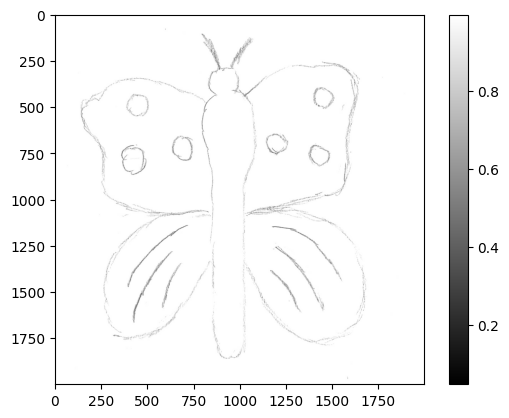

In [86]:
# depenging on the encoding of the image, we don't convert it into gray scale the same way.
if len(img_raw.shape) == 2:
    img = img_raw / 256
elif img_raw.shape[2] == 2:
    img = img_raw[:, :, 0] / 256
elif img_raw.shape[2] == 3:
    img = rgb2gray(img_raw)
elif img_raw.shape[2] == 4:
    img = rgb2gray(img_raw[:, :, :3]) * (img_raw[:, :, 3] / 256)
else:
    raise ValueError(f"invalid image shape: {img_raw.shape}")

size = min(img.shape[0], img.shape[1])
print(f"shape: {img.shape}")

plt.imshow(img, cmap="gray")
plt.colorbar()
plt.show()

There are 3 challenges when we want to find the contours of the drawing:
- the pen creates a complex texture on the image (and this depends on the pen)
- the thickness of the line varies a lot in the drawing
- some lines are "frayed", with multiple strokes approximately at the same place.

Let's zoom in at one particular location:

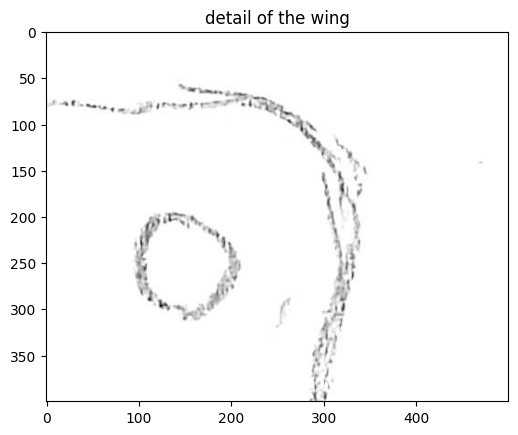

In [87]:
sub_image = img[200:600, 1300:1800]
plt.imshow(sub_image, cmap="gray")
plt.title("detail of the wing")
plt.show()

To solve the problem of the texture, we use a gaussian filter. This will blur our image to get a more uniform texture.

Then, we use a local thresholding: for each pixel, we look at a small region around it, we compute a threshold, and we look if the value is greater than it.

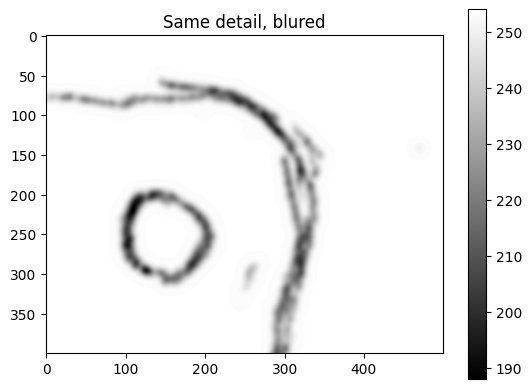

In [88]:
img = gaussian(img, sigma=size/500)
sub_image = img[200:600, 1300:1800]
plt.imshow((255*sub_image).astype(np.uint8), cmap="gray")
plt.colorbar()
plt.title("Same detail, blured")
plt.show()

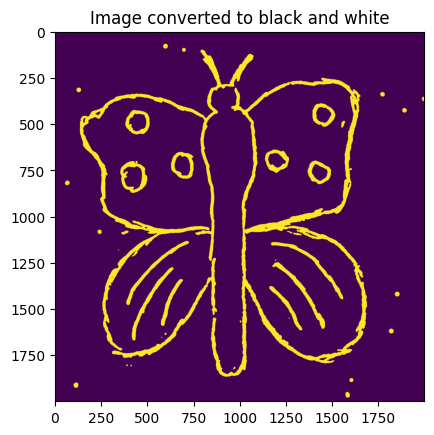

In [89]:
block_size = 2*(size // 20)+1
t = threshold_local(img, block_size)
img_binary = img < t
plt.imshow(img_binary)
plt.title("Image converted to black and white")
plt.show()

We now have black and white pixels, but we did not solve the issue of multiple strokes. And a new artefact appeared: small dots everywhere.
We follow the methodoloy of the paper and perform a dilation.

But we don't know what diameter to use !
In order to get it, we first it to compute the thickness map.

We erode the image iteratively, and for each pixel we keep track of the moment at which it disappeared.

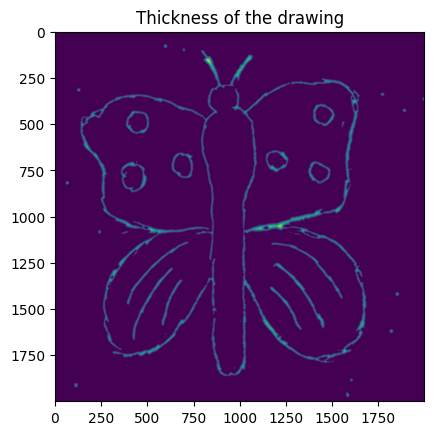

In [90]:
thicknesses = np.zeros_like(img_binary, dtype=int)

max_line_width_detection = img_binary.copy()
i = 0
while np.sum(max_line_width_detection) > 0:
    # iterate the erosion
    tmp = erosion(max_line_width_detection)
    # find the difference
    diff = max_line_width_detection ^ tmp > 0
    thicknesses[diff] = i
    max_line_width_detection = tmp
    i += 1

plt.imshow(thicknesses)
plt.title("Thickness of the drawing")
plt.show()

We barely see the thickness. We will make it more visible by finding the maximum values of thickness locally.

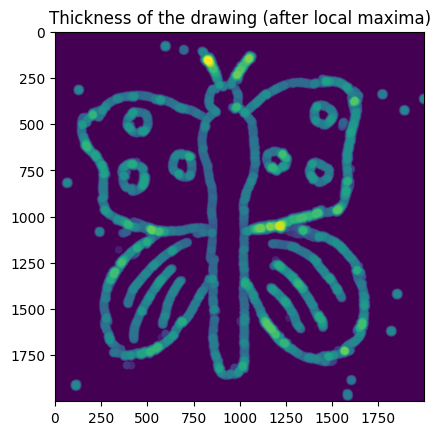

In [91]:
thicknesses = ndi.maximum_filter(thicknesses, footprint=disk(size/100))
plt.imshow(thicknesses)
plt.title("Thickness of the drawing (after local maxima)")
plt.show()

Finally, we can compute the value of the dilation parameter.

We could chose the maximum thickness, but if the thickness of the drawing is not uniform, we will a lot of details in regions where the thickness is very small.

After some experimentation, we decided to take the median of all thickness values.

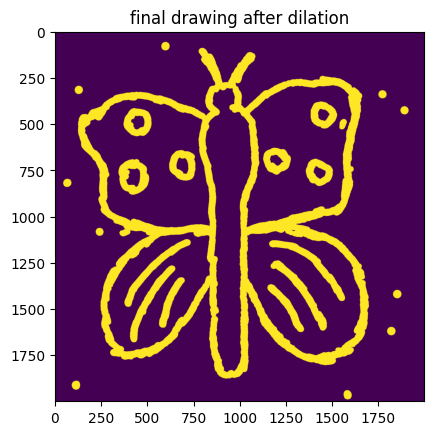

In [92]:
c = int(np.median(thicknesses[thicknesses > 0]))

# remove holes, objects and dilate
img_binary = remove_small_objects(img_binary, 4*c*c)
img_binary = remove_small_holes(img_binary, 4*c*c)
img_binary = dilation(img_binary, disk(c))
plt.imshow(img_binary)
plt.title("final drawing after dilation")
plt.show()

## Skeleton and topological graph

Once we have a nice black and white image, we can create the skeleton very easily using iterative thining.


In [93]:
from skimage.morphology import skeletonize
import scipy
from bez.topo_graph import extract_simple_topology_from_skeleton, extract_topology_from_skeleton
from bez.viz import visualize_topo

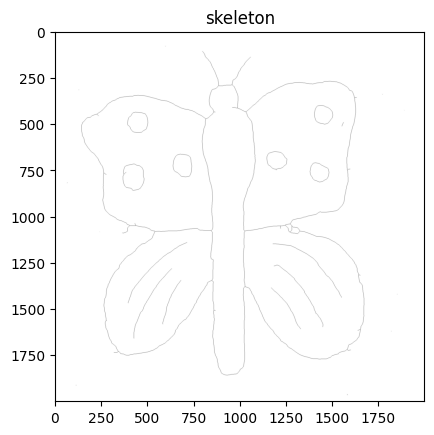

In [94]:
skeleton = skeletonize(img_binary, method="zhang")

plt.imshow(1-skeleton, cmap="gray")
plt.title("skeleton")
plt.show()

Once we have this graph, we traverse it in order to get the pixel chains. 

This is not explained explicitely in the original paper, but the trick is to look at the **number of neighbours** in the skeleton. Indeed, most nodes in the skeleton have only 3 neighbours. If it is not the case, we call it a "special" pixel

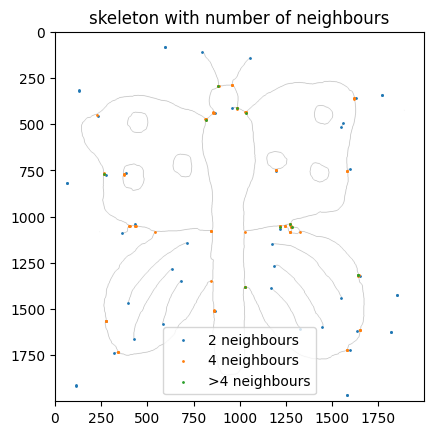

In [95]:
kernel = np.ones((3, 3), dtype=int)

neighbours = scipy.signal.convolve2d(
    skeleton.astype(int), kernel, mode="same"
)
neighbours*= skeleton
plt.imshow(1-skeleton, cmap="gray")
plt.scatter(np.where(neighbours == 2)[1], np.where(neighbours == 2)[0], label="2 neighbours", s=1)
plt.scatter(np.where(neighbours >= 4)[1], np.where(neighbours >= 4)[0], label="4 neighbours", s=1)
plt.scatter(np.where(neighbours > 4)[1], np.where(neighbours > 4)[0], label=">4 neighbours", s=1)
plt.legend()
plt.title("skeleton with number of neighbours")
plt.show()

We use this information to perform a graph traversal, from arbitrary pixels to "special" pixels.
For the special case of loops, we break them into a chain that ends where it starts.

number of nodes: 147


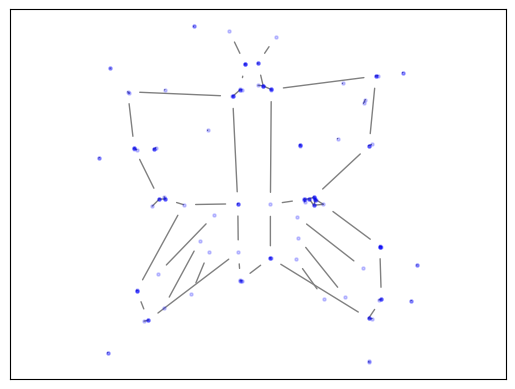

In [96]:
topo_graph = extract_topology_from_skeleton(skeleton)
visualize_topo(topo_graph, visu_radius=5, opacity=0.2)
print(f"number of nodes: {len(topo_graph.nodes())}")
plt.show()

This graph can be used for the next steps. Unfortunately, we can see that some groups of pixels are clustered together, which will cause a lot of problems.

With a modified algorithm, we are able to merge some of these clusters together.

number of nodes: 74


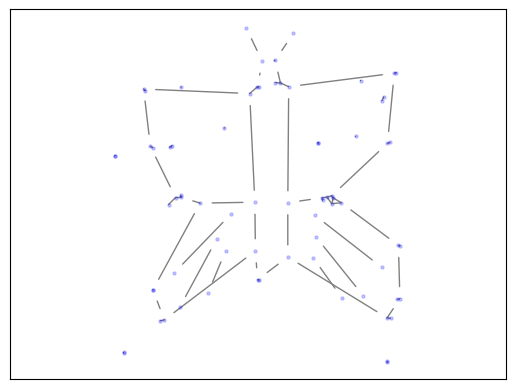

In [97]:
topo_graph = extract_simple_topology_from_skeleton(skeleton)
visualize_topo(topo_graph, visu_radius=5, opacity=0.2)
print(f"number of nodes: {len(topo_graph.nodes())}")
plt.show()

## Hyper graph and bezier fiting

Once we have our hypergraph, we can start to use bezier curves to approximate it.
Since it is a simple least square problem, we have derived the closed solution in the form of a linear system to solve.
The code below shows this logic.
Here $q(t)$ is a vector defined as 
$$
q(t) = \begin{pmatrix}
(1-t)^3 \\ 3 t (1-t)^2 \\ 2 t^2 (1-t) \\ t^3
\end{pmatrix}
$$

```python
def fit_bezier(traj, t):
    traj_x, traj_y = traj
    m = np.zeros((4, 4))
    bx = np.zeros(4)
    by = np.zeros(4)

    # this equation follows from the minimization of the pixel standard distance
    for i in range(k):
        q = interpolant(t, degree)
        m[i] = np.sum(weights * (q * q[i]), axis=1)
        bx[i] = np.sum(weights * (traj_x * q[i]))
        by[i] = np.sum(weights * (traj_y * q[i]))

    # We use lstsq because the matrix is not always full-rank.
    # For example, if the degree of the bezier is greater than the length of "traj"
    x_fit = np.linalg.lstsq(m, bx)[0]
    y_fit = np.linalg.lstsq(m, by)[0]
    return np.array([x_fit, y_fit])
```

In [71]:
from bez.refinement import  refine
from bez.hypergraph import HyperGraph
from bez.viz import visualize_hyper
from bez.global_optim import optimisation, fit_hyperedge

In [72]:
hyper = HyperGraph(topo_graph)

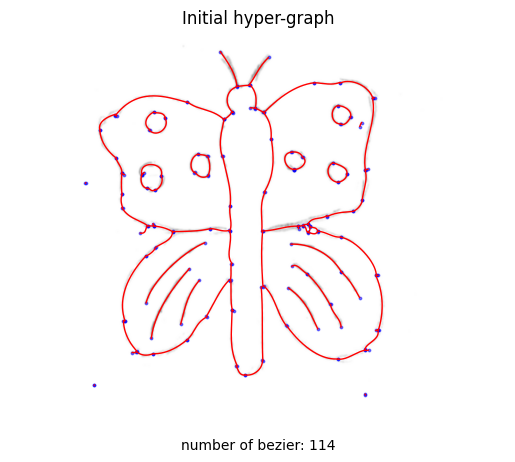

In [98]:
for h in hyper.all_hyperedges():
    fit_hyperedge(h)
visualize_hyper(hyper, offset=0)
plt.imshow(img, alpha=0.5, cmap="gray")
ax = plt.gca()
ax.axis("off")
plt.title("Initial hyper-graph")
ax.text(0.5, -0.1, f"number of bezier: {len(hyper)}", ha="center", va="top", transform=ax.transAxes)
plt.show()

The main issue with this initial hypergraph is that some curves should be broken down to better fit the image.
We implement the next part of the paper, a dichotomy-based refinement.

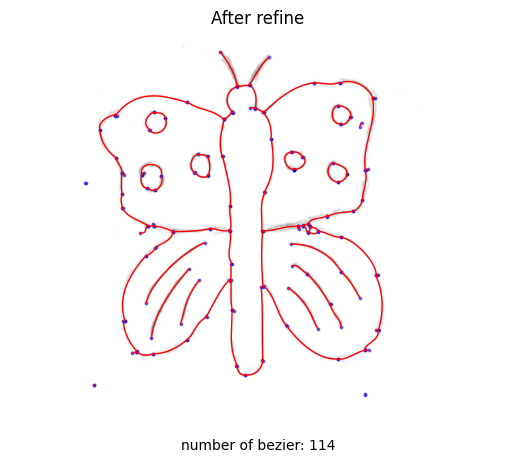

In [99]:
topo_graph = refine(topo_graph)
hyper = HyperGraph(topo_graph)
for h in hyper.all_hyperedges():
    fit_hyperedge(h)
visualize_hyper(hyper, offset=0)
plt.imshow(img, alpha=0.5, cmap="gray")
ax = plt.gca()
ax.axis("off")
plt.title("After refine")
plt.text(.5,-0.1,f"number of bezier: {len(hyper)}", fontsize=10, ha='center', va='top',  transform=ax.transAxes)
plt.show()

Now, we have to implement what is probably the most difficult part of the paper: the global optimisation.


We will manipulate sequences of edges, that we will call **hyperedges**. The intuition if they are multiple chains of pixels aligned with each other in the topological graph, they should be grouped together to form a longer chain.

This optimisation process is based on the idea of doing **perturbations** on these sequences.

Since the paper is not very explicit about these perturbations, we implemented it in a slightly different (but similar) way.

We first sample pairs of hyperedges $(U, V)$ such that $U$ end at a node that is anywhere inside $V$. We call such a configuation a "T" configuration.

![](../images/schema_t.svg)

Note that hyperedges are oriented. Once we sample one "T", we can apply 6 different transformations:

- increase or decrease the degree of $V$
- splitting V into 2 (if it has more than 3 nodes)
- overlaping V onto U (here, $V$ will become $(y, x, c, d)$)
- dissociating V from U (for that, the last edge of V must be in U)
- merging V and U. This is only possible when the T is in the special configuration showed below:

![](../images/schema_t2.svg)

We add a special transformation: **reverse**. As the name suggests, we reverse the order of all nodes in the sequence.

With the addition of this transformation, this is completely equivalent to the transformations proposed by the paper.


We try to chose the same parameters as the paper each time we can, to be able to compare results.

In [100]:
lam = 0.9
temp = 0.5
t_min = 0.05
mu = 0.3
t_decrease = 0.99 ** (1/len(topo_graph.nodes))
error = optimisation(hyper, lam=lam, mu=mu, temp=temp, t_decrease=t_decrease, t_min=t_min)

100%|█████████████████████████████████████████████████████████████████████████████████| 27034/27034 [00:09<00:00, 2715.18it/s]


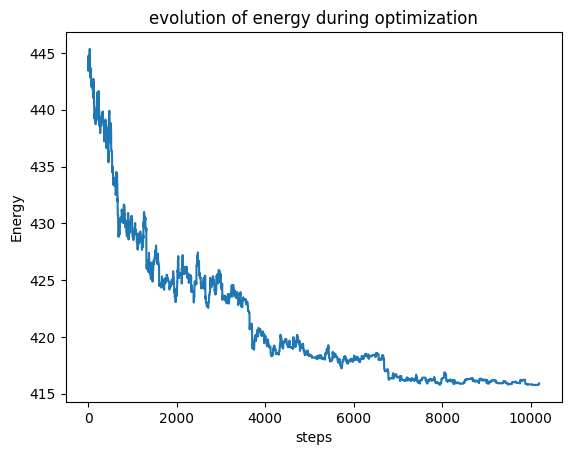

In [101]:
plt.plot(range(len(error)), error)
plt.ylabel("Energy")
plt.xlabel("steps")
plt.title("evolution of energy during optimization")
plt.show()

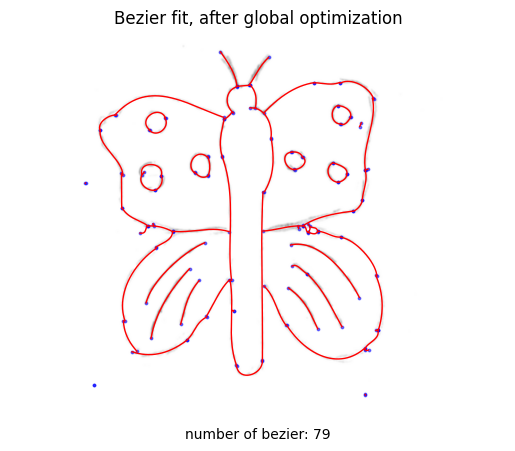

In [102]:
visualize_hyper(hyper)
plt.imshow(img, alpha=0.5, cmap="gray")
ax = plt.gca()
ax.axis("off")
plt.title("Bezier fit, after global optimization")
ax.text(0.5, -0.1, f"number of bezier: {len(hyper)}", ha="center", transform=ax.transAxes)
plt.show()

If we look closely, we see that some lines do not join exactly at the same point. It is logical, since every curve fitting is independent. 
The way to fix this problem is specified in the paper, but not exactly.

We chose to implement what seemed like a reasonnable solution.

First for the point-edges junctions, we look again at all our "T" configurations (see above) and force the control point of the incoming curve to fall exactly on the other curve.

For the point-point junctions, we compute the barycenter $B$ of all the points that are supposed to arrive at the same position, and we force the control point of each incoming edge to be $B$.

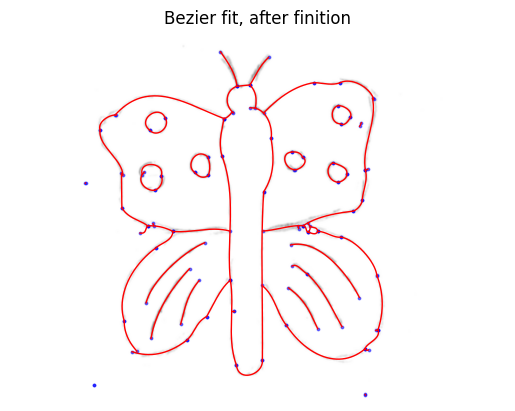

In [103]:
hyper.finition()
visualize_hyper(hyper)
plt.imshow(img, alpha=0.5, cmap="gray")
ax = plt.gca()
ax.axis("off")
plt.title("Bezier fit, after finition")
plt.show()

## SVG export

In [24]:
from IPython.display import SVG
from bez.app import generate_svg_str

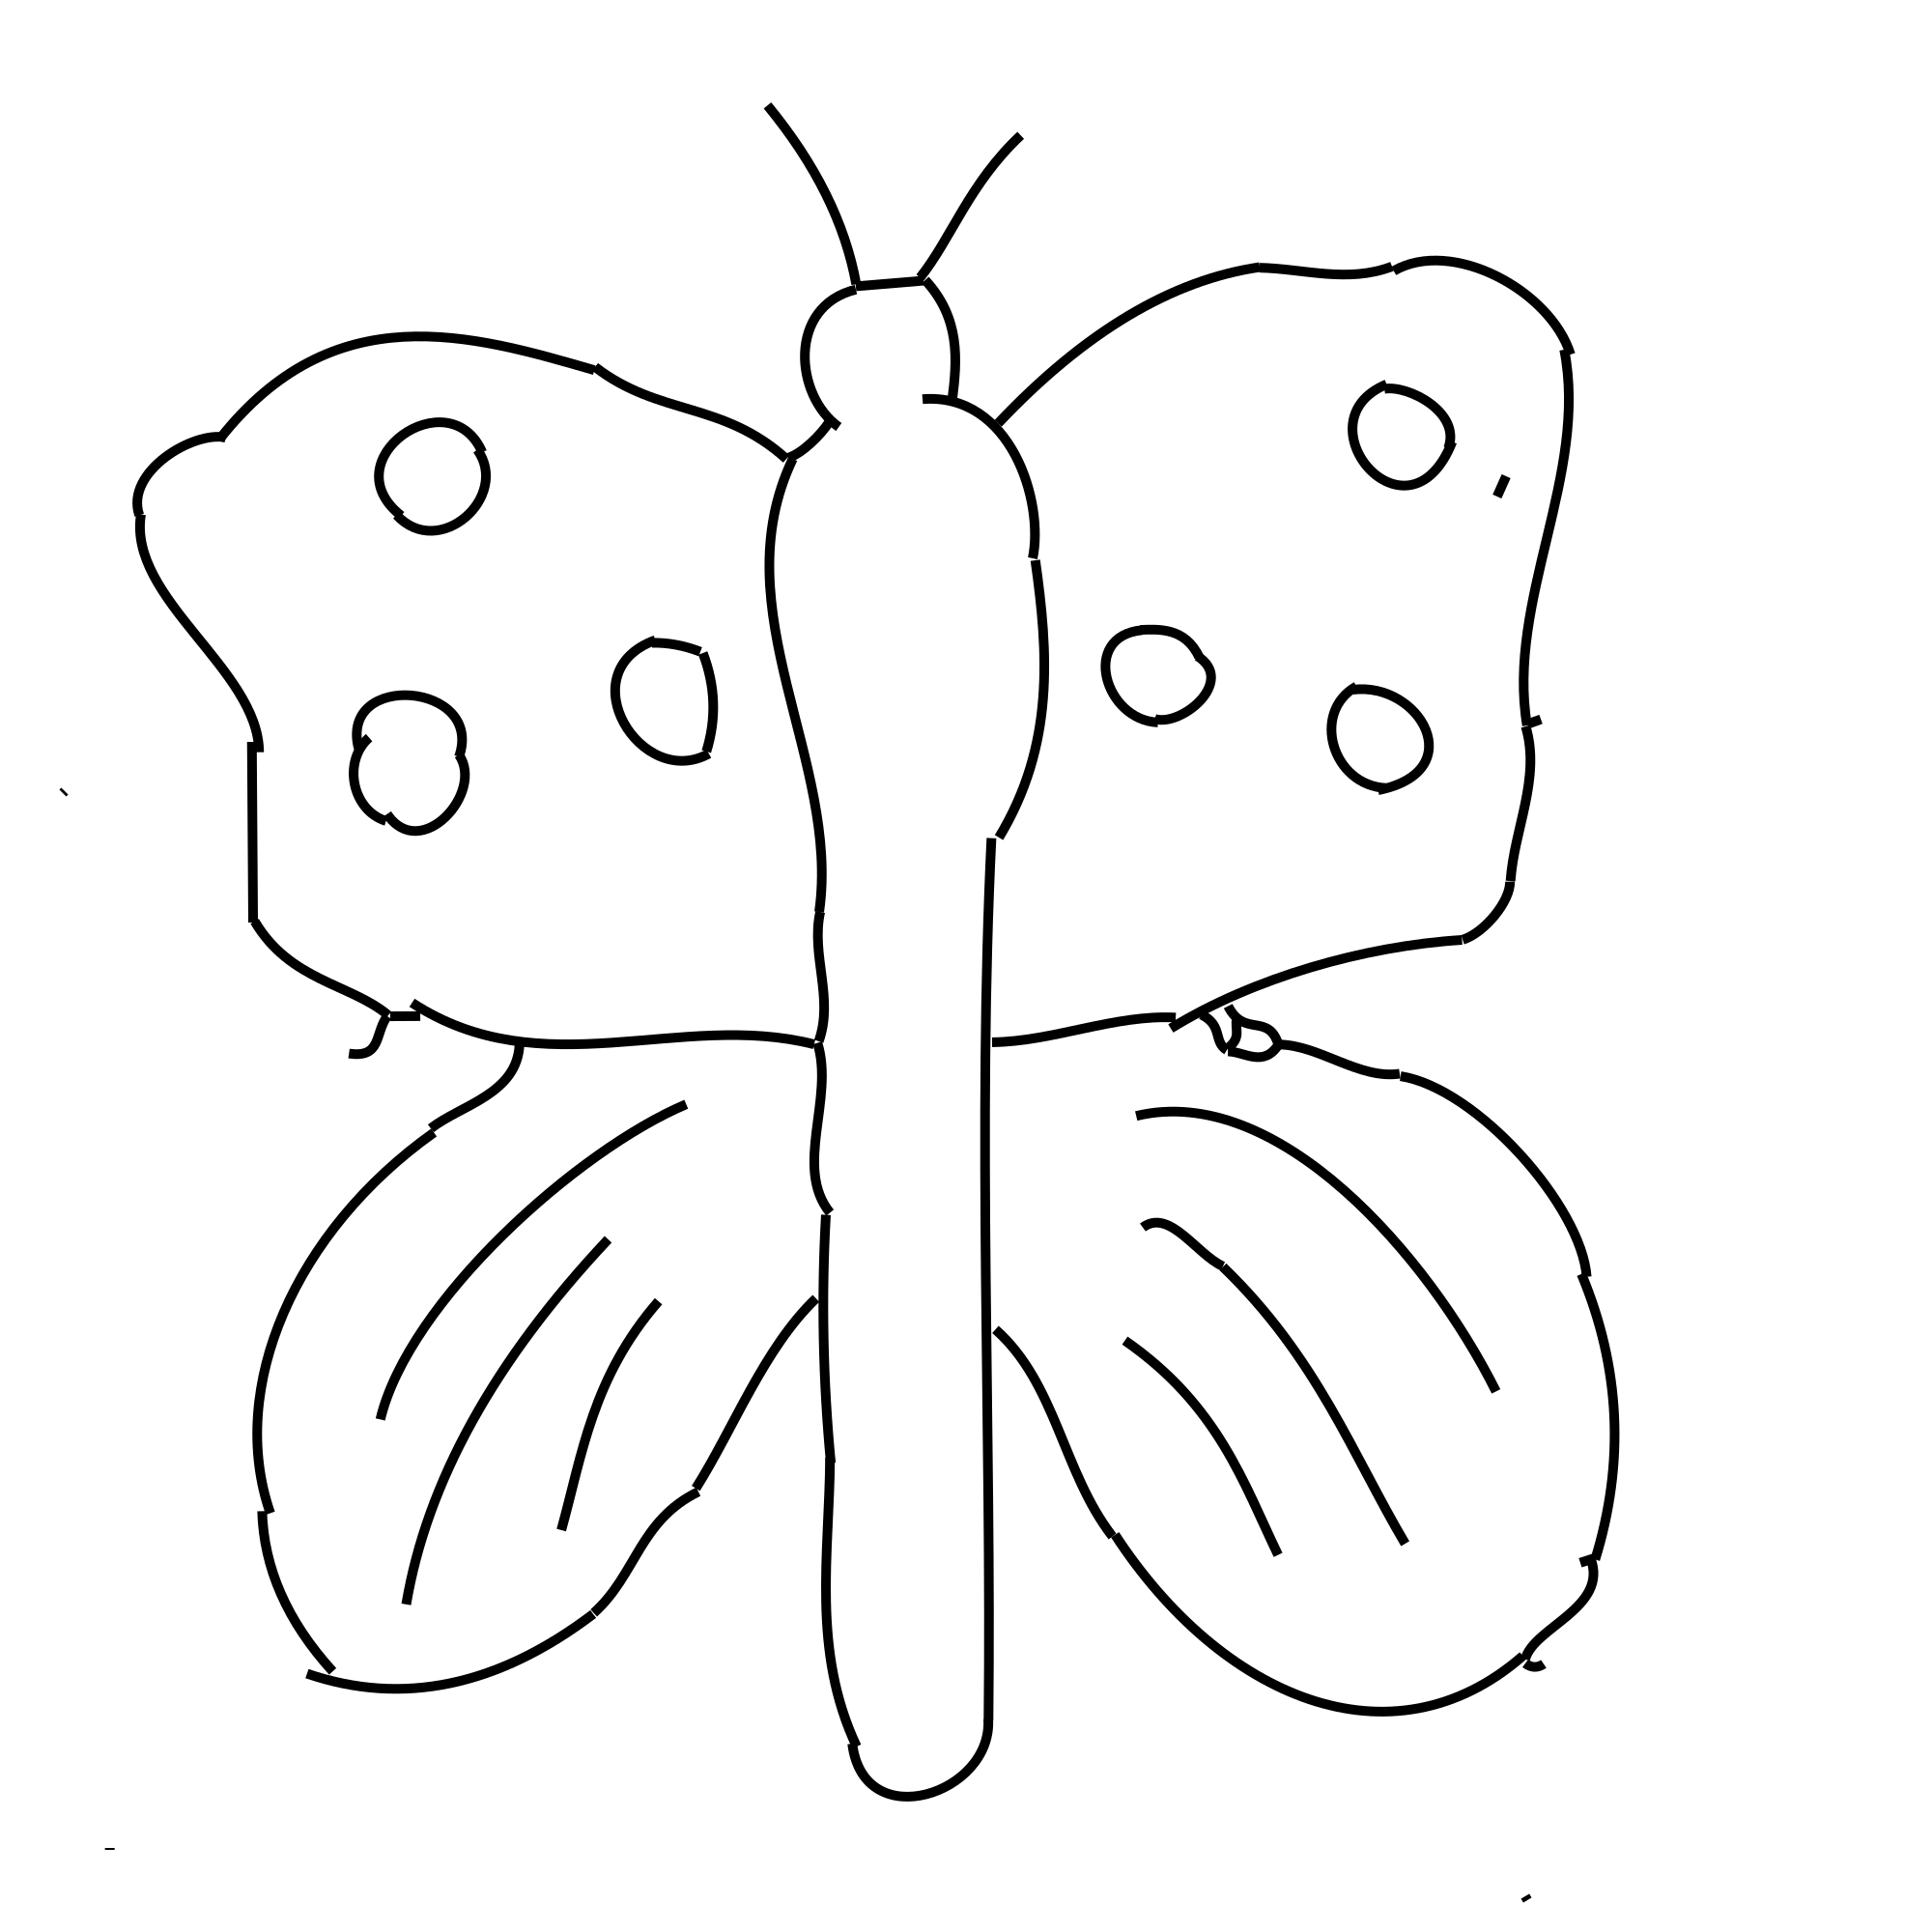

In [25]:
out = generate_svg_str(img.shape, hyper, stroke_width=10)
SVG(out)

In [29]:
from bez.app import show_example

100%|█████████████████████████████████████████████████████████████████████████████████| 46050/46050 [00:26<00:00, 1719.28it/s]


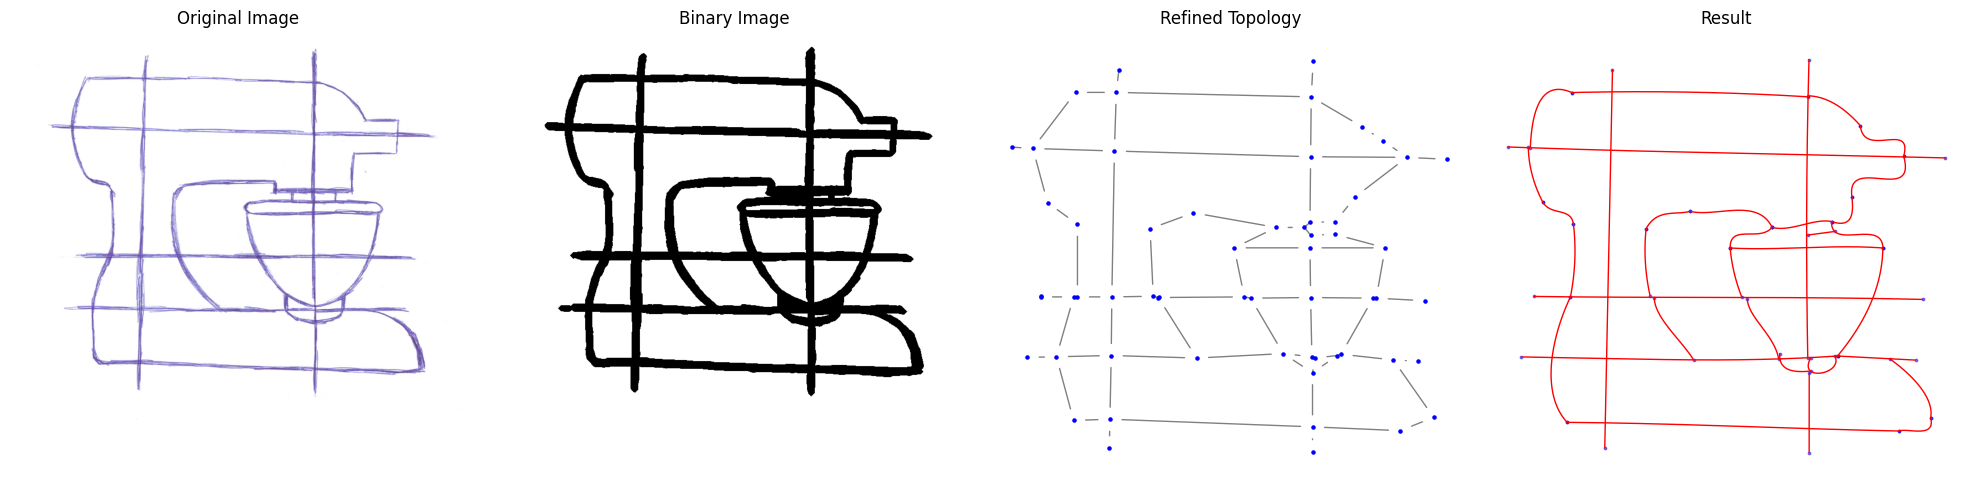

In [45]:
show_example(ROOT_DIR / "data/original_paper/figure_2/input.png")

100%|█████████████████████████████████████████████████████████████████████████████████| 46050/46050 [00:25<00:00, 1779.52it/s]


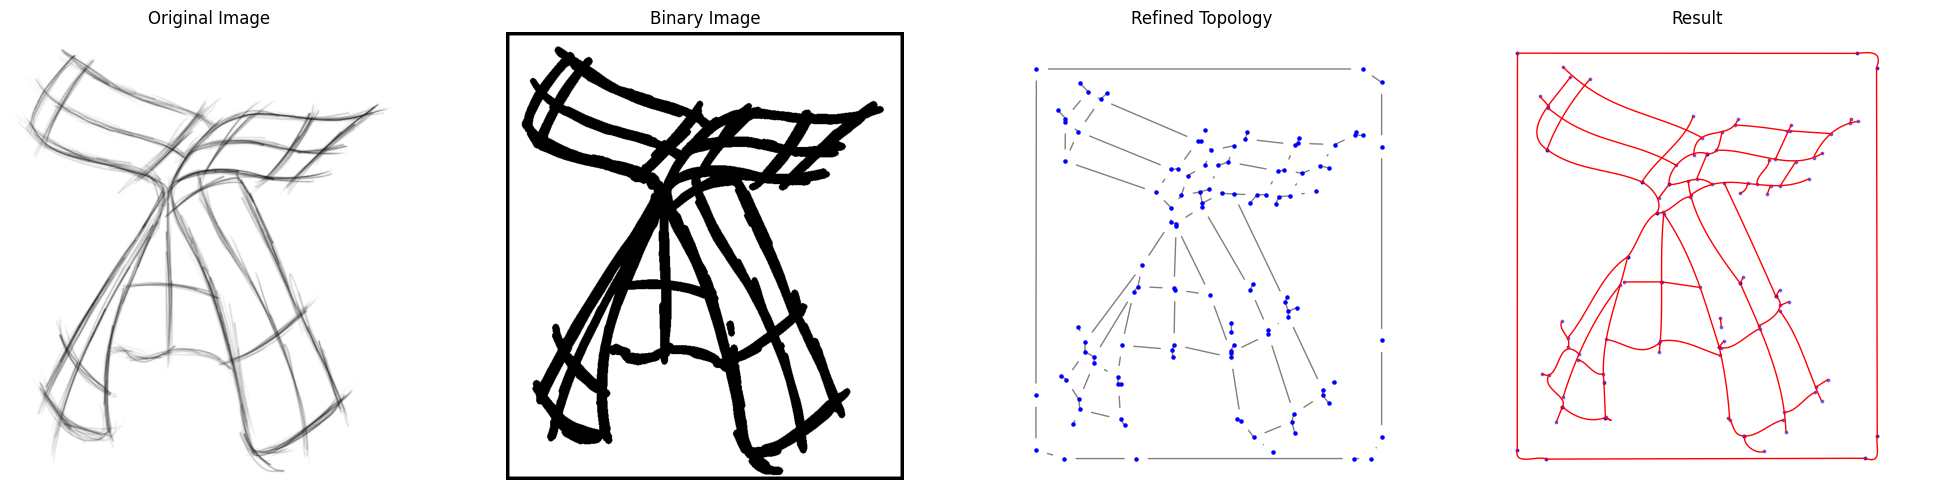

In [51]:
show_example(ROOT_DIR / "data/original_paper/figure_1/input.png")

100%|█████████████████████████████████████████████████████████████████████████████████| 46050/46050 [00:20<00:00, 2212.85it/s]


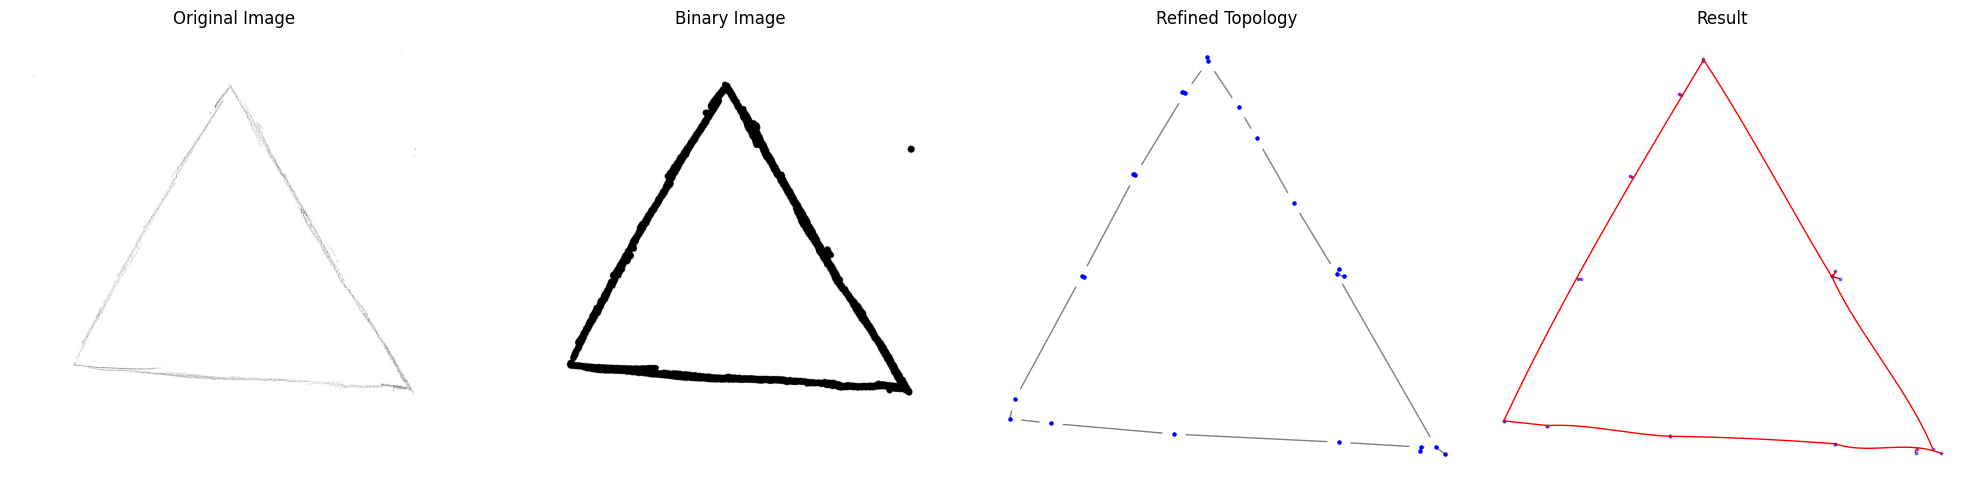

In [46]:
show_example(ROOT_DIR / "data/sketches/triangle.png")

100%|█████████████████████████████████████████████████████████████████████████████████| 46050/46050 [00:19<00:00, 2397.18it/s]


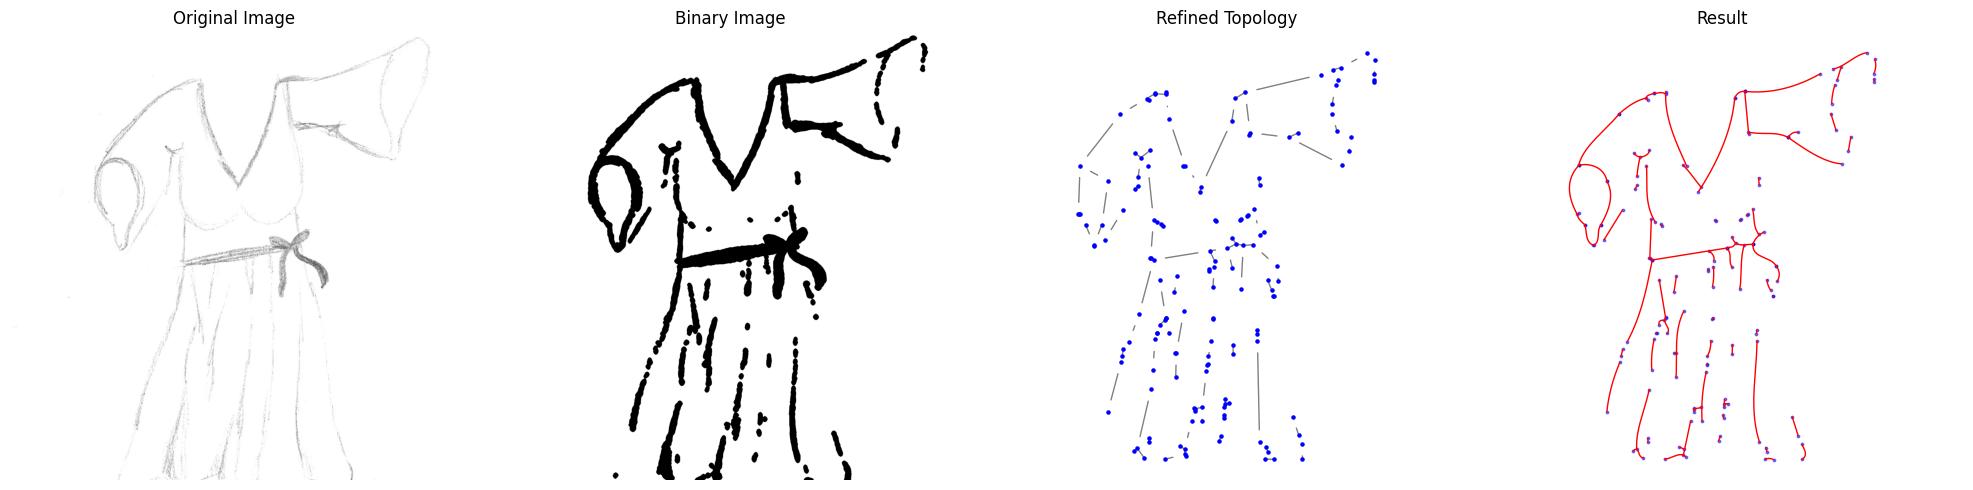

In [47]:
show_example(ROOT_DIR / "data/sketches/dress.png")

100%|█████████████████████████████████████████████████████████████████████████████████| 46050/46050 [00:16<00:00, 2787.96it/s]


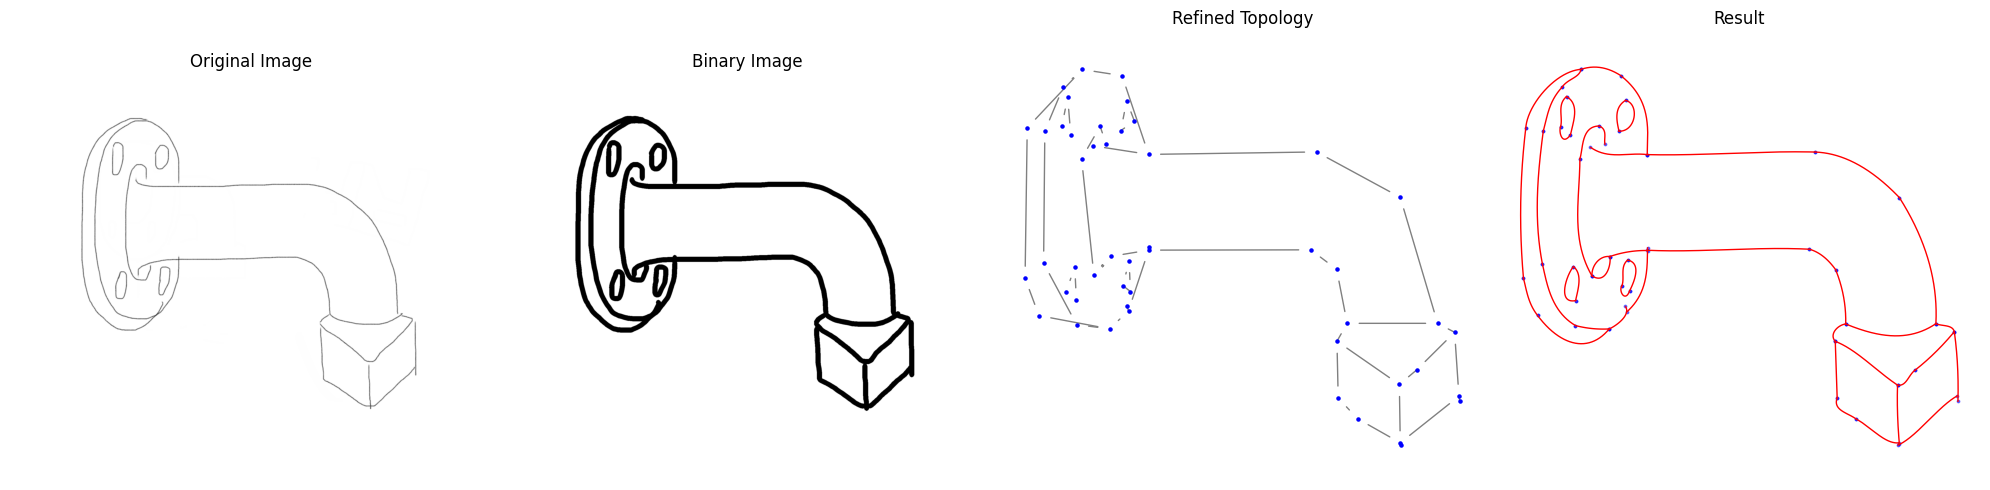

In [48]:
show_example(ROOT_DIR / "data/CAD_dataset/Dataset_B/ESB_Sketches/90 degree elbows/001_1.png")

100%|█████████████████████████████████████████████████████████████████████████████████| 46050/46050 [00:18<00:00, 2542.79it/s]


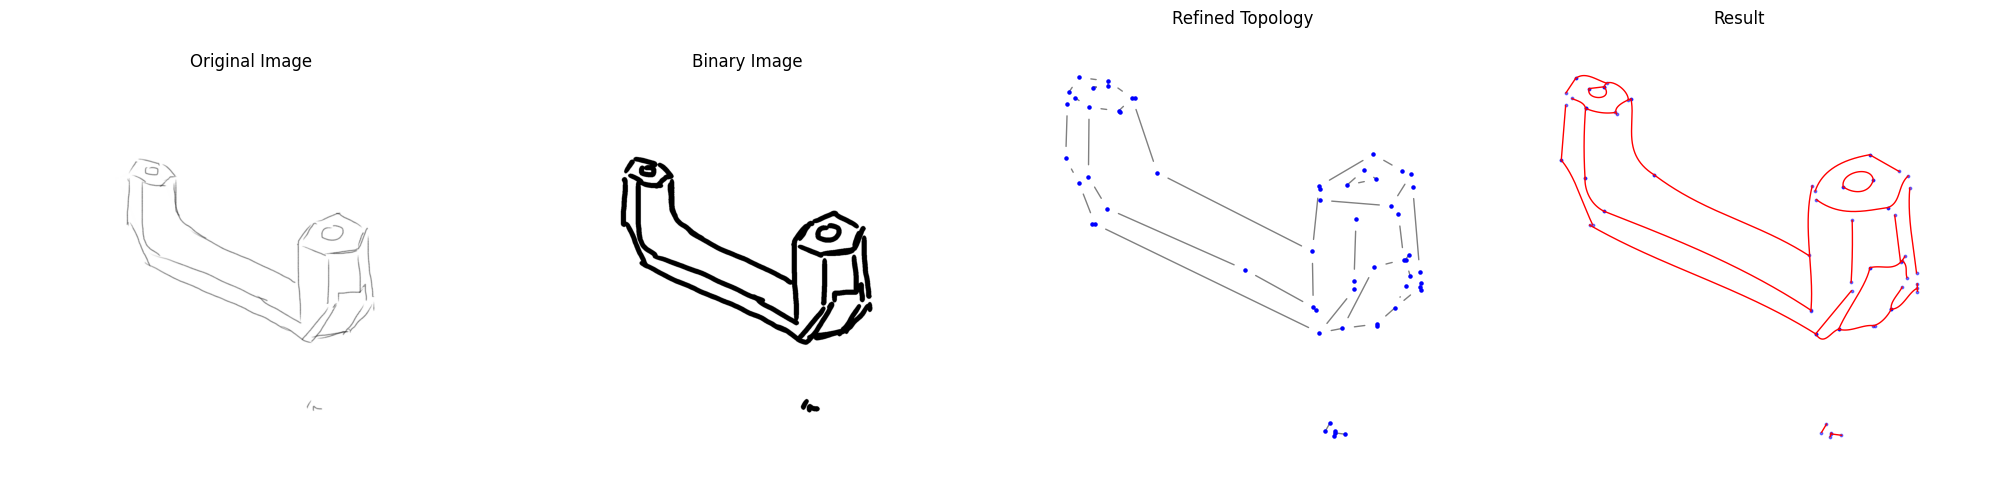

In [49]:
show_example(ROOT_DIR / "data/CAD_dataset/Dataset_B/ESB_Sketches/U shaped parts/010_1.png")

100%|█████████████████████████████████████████████████████████████████████████████████| 46050/46050 [00:19<00:00, 2335.83it/s]


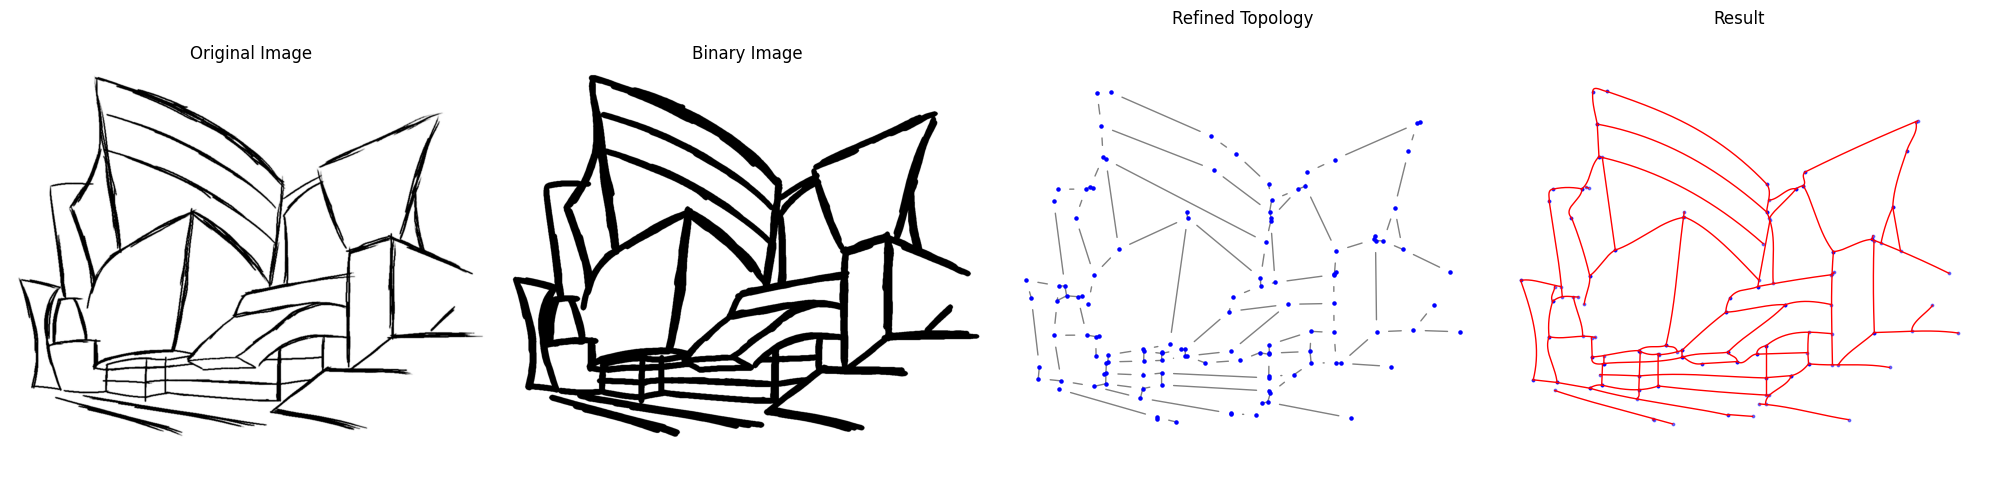

In [50]:
show_example(ROOT_DIR / "data/original_paper/figure_10/archi.png")

100%|█████████████████████████████████████████████████████████████████████████████████| 46050/46050 [00:17<00:00, 2597.66it/s]


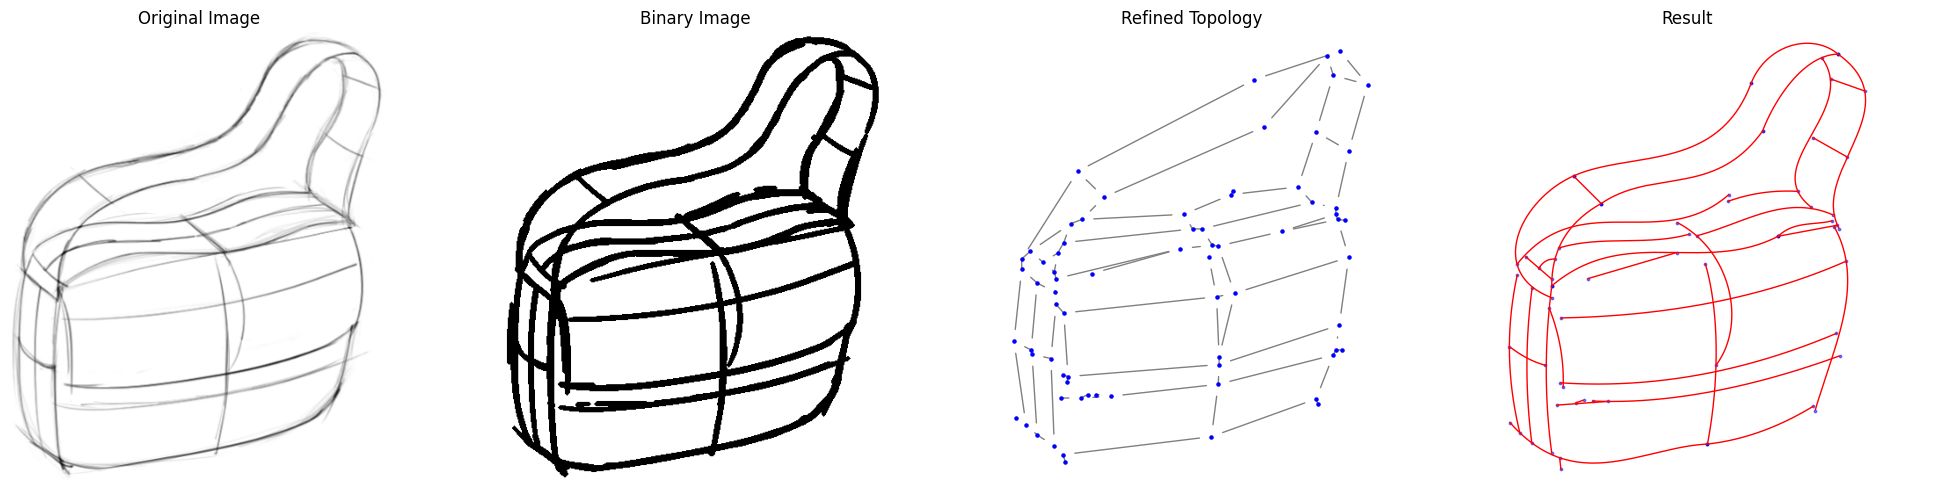

In [52]:
show_example(ROOT_DIR / "data/original_paper/figure_14/bag/input.png")